In [3]:
import pandas as pd
import re
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

In [4]:
compas_scores_two_y_unmodified = pd.read_csv('data/compas-scores-two-years.csv')

# Fjern data som i ProPublica:
compas_scores_two_y_unmodified = compas_scores_two_y_unmodified[compas_scores_two_y_unmodified['days_b_screening_arrest'] <= 30]
compas_scores_two_y_unmodified = compas_scores_two_y_unmodified[compas_scores_two_y_unmodified['days_b_screening_arrest'] >= -30]

# Drop unødvendige datakolonner:
compas_scores_two_y = compas_scores_two_y_unmodified.drop(columns=['name', 'first', 'last', 'compas_screening_date', 'in_custody', 'out_custody', 'c_jail_in', 'c_case_number', 
                                                        'c_jail_out', 'start', 'end', 'event', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'days_b_screening_arrest',
                                                        'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'r_case_number', 'r_charge_degree', 
                                                        'r_days_from_arrest', 'r_offense_date', 'r_jail_in', 'r_jail_out', 'violent_recid', 'vr_case_number',
                                                        'vr_charge_degree', 'vr_offense_date', 'type_of_assessment', 'screening_date', 'v_screening_date'])

In [5]:
# Se på sanne positive, falske negative, etc...

    # Del dataframet i low risk (l_risk) og high og medium risk (mh_risk)
def l_mh_risk_split(data):
    l_risk = data[data['score_text'] == 'Low'] # Low risk
    mh_risk = data[data['score_text'] == 'Medium'] # Start med bare medium risk...
    mh_risk = pd.concat([mh_risk, data[data['score_text'] == 'High']]) # ...og legg til high risk i samme dataframe.
    return l_risk, mh_risk

    # Funksjoner som teller antall sanne positive, falske negative, etc...:
def true_pos(data, rates):
    _, mh_risk = l_mh_risk_split(data)
    for row in mh_risk.iloc():
        if row['two_year_recid'] == True:
           rates['true_pos'] += 1
    return rates

def false_pos(data, rates):
    _, mh_risk = l_mh_risk_split(data)
    for row in mh_risk.iloc():
        if row['two_year_recid'] == False:
            rates['false_pos'] += 1
    return rates

def true_neg(data, rates):
    l_risk, _ = l_mh_risk_split(data)
    for row in l_risk.iloc():
        if row['two_year_recid'] == False:
            rates['true_neg'] += 1
    return rates

def false_neg(data, rates):
    l_risk, _ = l_mh_risk_split(data)
    for row in l_risk.iloc():
        if row['two_year_recid'] == True:
            rates['false_neg'] += 1
    return rates
            
rate_types = (true_pos, false_pos, true_neg, false_neg) # Konstruer liste over funksjonene over, så de kan kalles i rekkefølge i for-loop.

def calc_rates(data):
    rates = {'true_pos': 0,  # Konstruér dict over de forskjellige typene verdier...
             'false_pos': 0,
             'true_neg': 0,
             'false_neg': 0}
    for f in rate_types: # f er en av de fire funksjonene i rate_types...
        rates = f(data, rates) # Kaller alle fire funksjonene etter hverandre med rates som input - rates oppdateres hver gang, så alle verdiene blir utfylt til slutt.
    return rates

def calc_ppv(rates):
    return rates['true_pos'] / (rates['true_pos'] + rates['false_pos'])

rates = calc_rates(compas_scores_two_y) # Regner ut de fire verdiene for hele befolkningen

    # Regn ut positive prediktive verdier:
        # Konstruér dict for alle etnisiteter:
ppvs = {'all': 0,
        'caucasian': 0,
        'aa': 0, # aa = African American
        'men': 0,
        'women': 0}

        # Del dataframet i hvite, svarte, menn og kvinner:
caucasian_data = compas_scores_two_y[compas_scores_two_y['race'] == 'Caucasian']
aa_data = compas_scores_two_y[compas_scores_two_y['race'] == 'African-American']
men_data = compas_scores_two_y[compas_scores_two_y['sex'] == 'Male']
women_data = compas_scores_two_y[compas_scores_two_y['sex'] == 'Female']

        # Hele befolkningen:
ppvs['all'] = calc_ppv(rates)
        # Hvite:
caucasian_rates = calc_rates(caucasian_data)
ppvs['caucasian'] = calc_ppv(caucasian_rates)
        # Svarte:
aa_rates = calc_rates(aa_data)
ppvs['aa'] = calc_ppv(aa_rates)
        # Menn:
men_rates = calc_rates(men_data)
ppvs['men'] = calc_ppv(men_rates)
        # Kvinner:
women_rates = calc_rates(women_data)
ppvs['women'] = calc_ppv(women_rates)

# Skriv ut resultatene:
print(f'Verdier for hele befolkningen:\n\nSanne positive: {rates['true_pos']}\nFalske positive: {rates['false_pos']}\nSanne negative: {rates['true_neg']}\nFalske negative: {rates['false_neg']}\nPositiv prediktiv verdi: {ppvs['all']:.3f}\n')
print(f'Verdier for hvite:\n\nSanne positive: {caucasian_rates['true_pos']}\nFalske positive: {caucasian_rates['false_pos']}\nSanne negative: {caucasian_rates['true_neg']}\nFalske negative: {caucasian_rates['false_neg']}\nPositiv prediktiv verdi: {ppvs['caucasian']:.3f}\n')
print(f'Verdier for svarte:\n\nSanne positive: {aa_rates['true_pos']}\nFalske positive: {aa_rates['false_pos']}\nSanne negative: {aa_rates['true_neg']}\nFalske negative: {aa_rates['false_neg']}\nPositiv prediktiv verdi: {ppvs['aa']:.3f}\n')
print(f'Verdier for menn:\n\nSanne positive: {men_rates['true_pos']}\nFalske positive: {men_rates['false_pos']}\nSanne negative: {men_rates['true_neg']}\nFalske negative: {men_rates['false_neg']}\nPositiv prediktiv verdi: {ppvs['men']:.3f}\n')
print(f'Verdier for kvinner:\n\nSanne positive: {women_rates['true_pos']}\nFalske positive: {women_rates['false_pos']}\nSanne negative: {women_rates['true_neg']}\nFalske negative: {women_rates['false_neg']}\nPositiv prediktiv verdi: {ppvs['women']:.3f}\n')

Verdier for hele befolkningen:

Sanne positive: 1733
Falske positive: 1018
Sanne negative: 2345
Falske negative: 1076
Positiv prediktiv verdi: 0.630

Verdier for hvite:

Sanne positive: 414
Falske positive: 282
Sanne negative: 999
Falske negative: 408
Positiv prediktiv verdi: 0.595

Verdier for svarte:

Sanne positive: 1188
Falske positive: 641
Sanne negative: 873
Falske negative: 473
Positiv prediktiv verdi: 0.650

Verdier for menn:

Sanne positive: 1487
Falske positive: 788
Sanne negative: 1813
Falske negative: 909
Positiv prediktiv verdi: 0.654

Verdier for kvinner:

Sanne positive: 246
Falske positive: 230
Sanne negative: 532
Falske negative: 167
Positiv prediktiv verdi: 0.517



In [6]:
#Se om narkotikaforbrytelser har høyere tilbakefallsrate

drug_recidivist = 0
drug_recoveree = 0
drugs = dict()

def countRecidivism(v, counter_recidivist, counter_recoveree):
    if (v == 1):
        counter_recidivist += 1
        return False, counter_recidivist, counter_recoveree
    else:
        counter_recoveree += 1
        return True, counter_recidivist, counter_recoveree

def countDrug(m):
    drug = m.group(1)
    if (drug in drugs):
        drugs[drug] += 1
    else:
        drugs[drug] = 1
    return drug, drugs[drug]
        
for r in compas_scores_two_y.iloc:
    m = re.match(".*Possession of (.*)", str(r['r_charge_desc']))
    if (m == None): 
        continue
    _, drug_recidivist, drug_recoveree = countRecidivism(r['two_year_recid'], drug_recidivist, drug_recoveree)
    countDrug(m)

drug_recidivism = pd.DataFrame(data=drugs, index=["Number of crimes"])
#drug_recidivism = drug_recidivism.add(pd.Series({"Recidivists": drug_recidivist, "Recoverees": drug_recoveree}))
drug_stats = pd.DataFrame(index=["Number"]);
drug_stats = drug_stats.assign(Recidivists = drug_recidivist, Recoverees = drug_recoveree)
display(drug_stats, drug_recidivism)
print('Det er altså veldig mange narkotikaforbrytere som begår nye forbrytelser. Mest sannsynlig er det fordi de er avhengige. Det kan derfor være en idé å utelate disse fra fremtidige studier; de begår nye forbrytelser av en helt annen grunn enn de fleste andre forbrytere, og gjør derfor dataene skjeve.')

,Recidivists,Recoverees
Number,156,9


,Cocaine,Cannabis,Hydromorphone,Hydrocodone,Ethylone,Oxycodone,Methadone,Morphine,XLR11
Number of crimes,113,28,6,4,5,4,1,2,2


Det er altså veldig mange narkotikaforbrytere som begår nye forbrytelser. Mest sannsynlig er det fordi de er avhengige. Det kan derfor være en idé å utelate disse fra fremtidige studier; de begår nye forbrytelser av en helt annen grunn enn de fleste andre forbrytere, og gjør derfor dataene skjeve.


Fra Bayes' setning har vi at P(recid|high) er proposjonal med P(high|recid). Hvis P(high|recid) er lav, altså man har lav presisjon, vil det dermed si at P(recid|high) også er lav. Altså at man har svak positiv prediktiv verdi, som vil si mange falske positive i forhold til faktiske positive.

In [7]:
# Defining the sigmoid function
def sigmoid(z):
    z = np.array(z, dtype=np.float64)
    return np.where(z >= 0, 1/(1 + np.exp(-z)), np.exp(z)/(1 + np.exp(z)))

In [ ]:
# Extract relevant columns
X = compas_scores_two_y_unmodified[["age_cat", "race", "sex", "priors_count", "c_charge_degree", "two_year_recid"]]
# Specify the categories we want to isolate the effect or race from
categorical_cols = ["age_cat", "race", "sex", "c_charge_degree"]
# Create one-hot encodings for the non-numerical columns in X
X = pd.get_dummies(X, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')
# Remove superflous columns (example: sex_Female = True -> sex_Male = False)
X = X.drop(["age_cat_25 - 45", "race_Caucasian", "sex_Male", "c_charge_degree_F"], axis=1)
# Create dataframe that tells us whether or not the risk of recidivism was low
Y = (compas_scores_two_y_unmodified["score_text"] != "Low")

# Create logistic regression model
clf = LogisticRegression(max_iter=1000, tol=1e-8, random_state=42).fit(X, Y)
# Get the coefficients for all columns (sex_Female, etc.)
coefs = clf.coef_[0]
# Get the index of "race_African-American"
ind = X.columns.get_loc("race_African-American")

# Create control, for all columns being 0, which corresponds to a white male
# of age 25-45, convicted of a felony, without any criminal history and 
# no recidivism in two years
control = sigmoid(clf.intercept_)
racialBias = np.exp(coefs[ind]) / (1 - control + (control * np.exp(coefs[ind])))

print(racialBias)

[1.45303866]


,priors_count,two_year_recid,age_cat_Greater than 45,age_cat_Less than 25,race_African-American,race_Asian,race_Hispanic,race_Native American,race_Other,sex_Female,c_charge_degree_M
0,0,0,True,False,False,False,False,False,True,False,False
1,0,1,False,False,True,False,False,False,False,False,False
2,4,1,False,True,True,False,False,False,False,False,False
5,0,0,False,False,False,False,False,False,True,False,True
6,14,1,False,False,False,False,False,False,False,False,False


In [9]:
print("predict_proba shape:", clf.predict_proba(X).shape)
print("Unique labels:", np.unique(Y))
print(X.shape)
print(X.columns)

predict_proba shape: (6172, 2)
Unique labels: [False  True]
(6172, 11)
Index(['priors_count', 'two_year_recid', 'age_cat_Greater than 45',
       'age_cat_Less than 25', 'race_African-American', 'race_Asian',
       'race_Hispanic', 'race_Native American', 'race_Other', 'sex_Female',
       'c_charge_degree_M'],
      dtype='object')


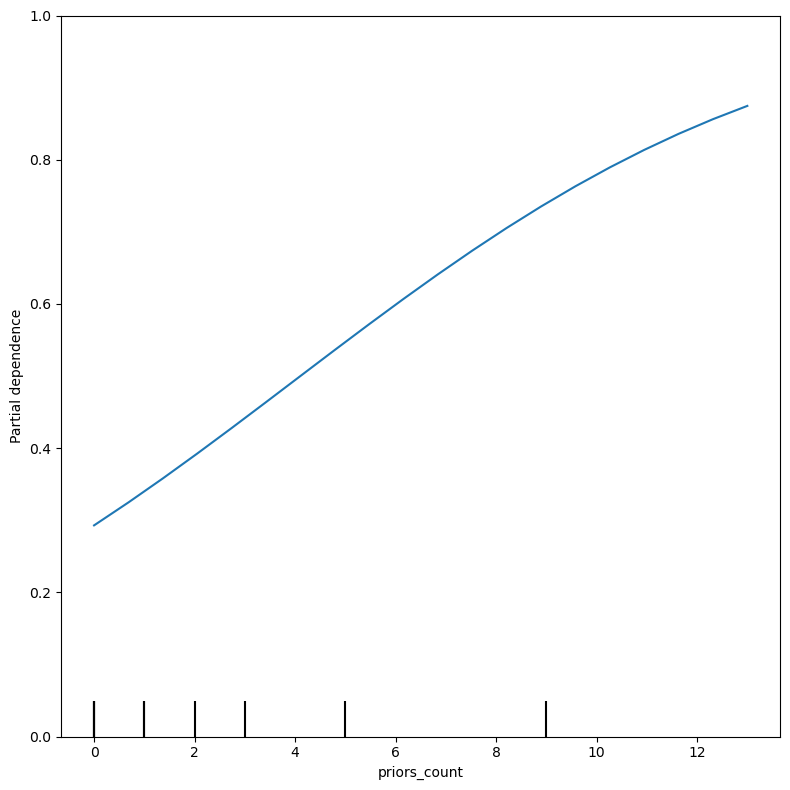

In [10]:
# Plot partial dependence
features = ['priors_count']

fig, ax = plt.subplots(figsize=(8, 8))
plots = PartialDependenceDisplay.from_estimator(clf, X, features=features, grid_resolution=20, ax=ax)
for ax in plots.axes_.ravel():
  try: 
    ax.set_ylim(0, 1)
  except AttributeError as e: 
    pass

fig.tight_layout()
plt.show()